In [67]:

%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
from tesa_m1 import ActiveSuspension


MOJE_S = 791

# Inicjalizacja modelu
model = ActiveSuspension(MOJE_S)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
from IPython.display import display, Markdown

# Skrót do obiektu modelu
m = model 

# Sekcja 1: Parametry
# Używamy f-stringa (rf""), podwójne klamry {{ }} to LaTeX, pojedyncze { } to zmienne Python
parametry_html = rf"""
## 1. Indywidualizacja Parametrów Projektowych

Parametry modelu ćwiartkowego zostały wyznaczone na podstawie indywidualnego numeru $S$.
Dla przyjętego **$S = {m.S}$**, wartości wynoszą:

### A. Parametry Masowe
* Masa resorowana (nadwozie):
$$m_s = 280 + 0.4 S = 280 + 0.4({m.S}) = \mathbf{{{m.ms:.1f}}} \text{{ kg}}$$
* Masa nieresorowana (zespół koła):
$$m_u = 35 + 0.05 S = 35 + 0.05({m.S}) = \mathbf{{{m.mu:.2f}}} \text{{ kg}}$$

### B. Parametry Sprężyste
* Sztywność zawieszenia:
$$k_s = (18 + 0.02 S) \cdot 10^3 = \mathbf{{{m.ks:.0f}}} \text{{ N/m}}$$
* Sztywność opony:
$$k_t = (150 + 0.05 S) \cdot 10^3 = \mathbf{{{m.kt:.0f}}} \text{{ N/m}}$$

### C. Parametry Tłumiące
* Współczynnik tłumienia zawieszenia:
$$c_s = (1.4 + 0.002 S) \cdot 10^3 = \mathbf{{{m.cs:.0f}}} \text{{ Ns/m}}$$
* Współczynnik tłumienia opony:
$$c_t = (0.4 + 0.001 S) \cdot 10^3 = \mathbf{{{m.ct:.0f}}} \text{{ Ns/m}}$$

### D. Element Wykonawczy
* Ograniczenie siły sterującej:
$$|u| \le \mathbf{{{m.u_max:.0f}}} \text{{ N}}$$
"""

display(Markdown(parametry_html))


## 1. Indywidualizacja Parametrów Projektowych

Parametry modelu ćwiartkowego zostały wyznaczone na podstawie indywidualnego numeru $S$.
Dla przyjętego **$S = 791$**, wartości wynoszą:

### A. Parametry Masowe
* Masa resorowana (nadwozie):
$$m_s = 280 + 0.4 S = 280 + 0.4(791) = \mathbf{596.4} \text{ kg}$$
* Masa nieresorowana (zespół koła):
$$m_u = 35 + 0.05 S = 35 + 0.05(791) = \mathbf{74.55} \text{ kg}$$

### B. Parametry Sprężyste
* Sztywność zawieszenia:
$$k_s = (18 + 0.02 S) \cdot 10^3 = \mathbf{33820} \text{ N/m}$$
* Sztywność opony:
$$k_t = (150 + 0.05 S) \cdot 10^3 = \mathbf{189550} \text{ N/m}$$

### C. Parametry Tłumiące
* Współczynnik tłumienia zawieszenia:
$$c_s = (1.4 + 0.002 S) \cdot 10^3 = \mathbf{2982} \text{ Ns/m}$$
* Współczynnik tłumienia opony:
$$c_t = (0.4 + 0.001 S) \cdot 10^3 = \mathbf{1191} \text{ Ns/m}$$

### D. Element Wykonawczy
* Ograniczenie siły sterującej:
$$|u| \le \mathbf{3000} \text{ N}$$


In [69]:
from IPython.display import display, Markdown

# Alias dla wygody
m = model 

wyprowadzenie_full_symbolic = rf"""
## 2. Model Matematyczny w Przestrzeni Stanu

### Równania różniczkowe
Układ 2-DOF opisany jest bilansem sił:

1. **Masa resorowana ($m_s$):**
$$m_{{s}}\ddot{{z}}_{{s}} = -k_{{s}}(z_{{s}}-z_{{u}}) - c_{{s}}(\dot{{z}}_{{s}}-\dot{{z}}_{{u}}) + u$$

2. **Masa nieresorowana ($m_u$):**
$$m_{{u}}\ddot{{z}}_{{u}} = k_{{s}}(z_{{s}}-z_{{u}}) + c_{{s}}(\dot{{z}}_{{s}}-\dot{{z}}_{{u}}) - k_{{t}}(z_{{u}}-r) - c_{{t}}(\dot{{z}}_{{u}}-\dot{{r}}) - u$$

### Definicja zmiennych
Przyjęto wektor stanu $x$ (z prędkością względną $x_4$) oraz uproszczony wektor zakłóceń $w$:
$$
x = \begin{{bmatrix}} z_s - z_u \\ \dot{{z}}_s \\ z_u - r \\ \dot{{z}}_u - \dot{{r}} \end{{bmatrix}}, \quad
w = \begin{{bmatrix}} r \\ \dot{{r}} \end{{bmatrix}}
$$

### Równanie Stanu ($\dot{{x}} = Ax + Bu + Ew$)
Dla parametrów indywidualnych ($S={m.S}$), macierze przyjmują postać:

**Macierz Dynamiki A:**
$$
A = \begin{{bmatrix}}
0 & 1 & 0 & -1 \\
-\frac{{k_s}}{{m_s}} & -\frac{{c_s}}{{m_s}} & 0 & \frac{{c_s}}{{m_s}} \\
0 & 0 & 0 & 1 \\
\frac{{k_s}}{{m_u}} & \frac{{c_s}}{{m_u}} & -\frac{{k_t}}{{m_u}} & -\frac{{c_s+c_t}}{{m_u}}
\end{{bmatrix}}
= \begin{{bmatrix}}
{m.A[0,0]:.0f} & {m.A[0,1]:.0f} & {m.A[0,2]:.0f} & {m.A[0,3]:.0f} \\
{m.A[1,0]:.2f} & {m.A[1,1]:.2f} & {m.A[1,2]:.2f} & {m.A[1,3]:.2f} \\
{m.A[2,0]:.0f} & {m.A[2,1]:.0f} & {m.A[2,2]:.0f} & {m.A[2,3]:.0f} \\
{m.A[3,0]:.2f} & {m.A[3,1]:.2f} & {m.A[3,2]:.2f} & {m.A[3,3]:.2f}
\end{{bmatrix}}
$$

**Macierz Wejść Sterujących B:**
$$
B = \begin{{bmatrix}} 0 \\ \frac{{1}}{{m_s}} \\ 0 \\ -\frac{{1}}{{m_u}} \end{{bmatrix}}
= \begin{{bmatrix}} 0 \\ {m.B[1,0]:.5f} \\ 0 \\ {m.B[3,0]:.5f} \end{{bmatrix}}
$$

**Macierz Zakłóceń E:**
$$
E = \begin{{bmatrix}} 0 & -1 \\ 0 & \frac{{c_s}}{{m_s}} \\ 0 & 0 \\ 0 & -\frac{{c_s}}{{m_u}} \end{{bmatrix}}
= \begin{{bmatrix}} 0 & -1 \\ 0 & {m.E[1,1]:.2f} \\ 0 & 0 \\ 0 & {m.E[3,1]:.2f} \end{{bmatrix}}
$$

### Równanie Wyjścia ($y = Cx + Du$)
[cite_start]Zdefiniowano wektor wyjść pomiarowych i metryk jakości:
$$y = [\dot{{z}}_s, \quad z_u - r, \quad z_s - z_u]^T$$

**Macierz Wyjścia C:**
$$
C = \begin{{bmatrix}}
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
1 & 0 & 0 & 0 
\end{{bmatrix}}
$$

**Macierz Bezpośrednia D:**
$$
D = \begin{{bmatrix}} 0 \\ 0 \\ 0 \end{{bmatrix}}
$$
"""

display(Markdown(wyprowadzenie_full_symbolic))


## 2. Model Matematyczny w Przestrzeni Stanu

### Równania różniczkowe
Układ 2-DOF opisany jest bilansem sił:

1. **Masa resorowana ($m_s$):**
$$m_{s}\ddot{z}_{s} = -k_{s}(z_{s}-z_{u}) - c_{s}(\dot{z}_{s}-\dot{z}_{u}) + u$$

2. **Masa nieresorowana ($m_u$):**
$$m_{u}\ddot{z}_{u} = k_{s}(z_{s}-z_{u}) + c_{s}(\dot{z}_{s}-\dot{z}_{u}) - k_{t}(z_{u}-r) - c_{t}(\dot{z}_{u}-\dot{r}) - u$$

### Definicja zmiennych
Przyjęto wektor stanu $x$ (z prędkością względną $x_4$) oraz uproszczony wektor zakłóceń $w$:
$$
x = \begin{bmatrix} z_s - z_u \\ \dot{z}_s \\ z_u - r \\ \dot{z}_u - \dot{r} \end{bmatrix}, \quad
w = \begin{bmatrix} r \\ \dot{r} \end{bmatrix}
$$

### Równanie Stanu ($\dot{x} = Ax + Bu + Ew$)
Dla parametrów indywidualnych ($S=791$), macierze przyjmują postać:

**Macierz Dynamiki A:**
$$
A = \begin{bmatrix}
0 & 1 & 0 & -1 \\
-\frac{k_s}{m_s} & -\frac{c_s}{m_s} & 0 & \frac{c_s}{m_s} \\
0 & 0 & 0 & 1 \\
\frac{k_s}{m_u} & \frac{c_s}{m_u} & -\frac{k_t}{m_u} & -\frac{c_s+c_t}{m_u}
\end{bmatrix}
= \begin{bmatrix}
0 & 1 & 0 & -1 \\
-56.71 & -5.00 & 0.00 & 5.00 \\
0 & 0 & 0 & 1 \\
453.66 & 40.00 & -2542.59 & -55.98
\end{bmatrix}
$$

**Macierz Wejść Sterujących B:**
$$
B = \begin{bmatrix} 0 \\ \frac{1}{m_s} \\ 0 \\ -\frac{1}{m_u} \end{bmatrix}
= \begin{bmatrix} 0 \\ 0.00168 \\ 0 \\ -0.01341 \end{bmatrix}
$$

**Macierz Zakłóceń E:**
$$
E = \begin{bmatrix} 0 & -1 \\ 0 & \frac{c_s}{m_s} \\ 0 & 0 \\ 0 & -\frac{c_s}{m_u} \end{bmatrix}
= \begin{bmatrix} 0 & -1 \\ 0 & 5.00 \\ 0 & 0 \\ 0 & -40.00 \end{bmatrix}
$$

### Równanie Wyjścia ($y = Cx + Du$)
[cite_start]Zdefiniowano wektor wyjść pomiarowych i metryk jakości:
$$y = [\dot{z}_s, \quad z_u - r, \quad z_s - z_u]^T$$

**Macierz Wyjścia C:**
$$
C = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
1 & 0 & 0 & 0 
\end{bmatrix}
$$

**Macierz Bezpośrednia D:**
$$
D = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}
$$


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- M1b. Weryfikacja (S=791) ---
Status: PASSED


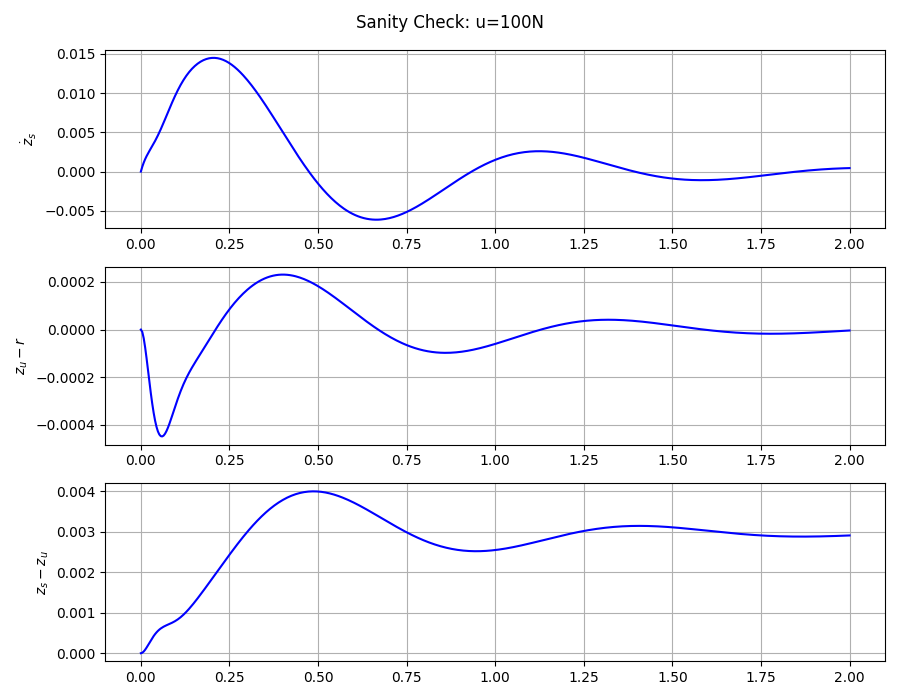

In [70]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
from tesa_m1 import ActiveSuspension
#Uruchomienie weryfikacji (M1b)
t, y, status = model.run_sanity_check()

# Wyświetlenie wykresów
if status == "PASSED":
    model.plot_sanity_check(t, y)
else:
    print("Popraw błędy w modelu przed generowaniem wykresów!")

In [71]:
from IPython.display import display, Markdown

m = model 

raport_pomiary_simple = rf"""
## M2. Definicja Układu Pomiarowego

Przyjęto konfigurację czujników mierzącą bezpośrednio wybrane zmienne stanu:
1. **Prędkość pionowa nadwozia**: $y_{{pom,1}} = \dot{{z}}_s = x_2$
2. **Ugięcie zawieszenia**: $y_{{pom,2}} = z_s - z_u = x_1$

### Równanie wyjścia pomiarowego
Wektor pomiarowy $y_{{pom}} = C_{{pom}}x + D_{{pom}}u$ przyjmuje postać:

$$
y_{{pom}} = \begin{{bmatrix}} \dot{{z}}_s \\ z_s - z_u \end{{bmatrix}} = \begin{{bmatrix}} x_2 \\ x_1 \end{{bmatrix}}
$$

Dla tej konfiguracji macierze pomiarowe są stałe (niezależne od parametrów $S$) i bezinercyjne ($D_{{pom}}=0$):

$$
C_{{pom}} = \begin{{bmatrix}}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{{bmatrix}}, \quad
D_{{pom}} = \begin{{bmatrix}} 0 \\ 0 \end{{bmatrix}}
$$

### Analiza Obserwowalności (M2a)
Analiza rzędu macierzy Kalmana dla przyjętego zestawu czujników:
"""

display(Markdown(raport_pomiary_simple))


## M2. Definicja Układu Pomiarowego

Przyjęto konfigurację czujników mierzącą bezpośrednio wybrane zmienne stanu:
1. **Prędkość pionowa nadwozia**: $y_{pom,1} = \dot{z}_s = x_2$
2. **Ugięcie zawieszenia**: $y_{pom,2} = z_s - z_u = x_1$

### Równanie wyjścia pomiarowego
Wektor pomiarowy $y_{pom} = C_{pom}x + D_{pom}u$ przyjmuje postać:

$$
y_{pom} = \begin{bmatrix} \dot{z}_s \\ z_s - z_u \end{bmatrix} = \begin{bmatrix} x_2 \\ x_1 \end{bmatrix}
$$

Dla tej konfiguracji macierze pomiarowe są stałe (niezależne od parametrów $S$) i bezinercyjne ($D_{pom}=0$):

$$
C_{pom} = \begin{bmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{bmatrix}, \quad
D_{pom} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}
$$

### Analiza Obserwowalności (M2a)
Analiza rzędu macierzy Kalmana dla przyjętego zestawu czujników:


In [72]:
import numpy as np
import control as ct

# Obliczenie macierzy obserwowalności
O_meas = ct.obsv(m.A, m.C_meas)
rank_O = np.linalg.matrix_rank(O_meas)
n_states = m.A.shape[0]

print(f"Wymiar stanu n: {n_states}")
print(f"Rząd macierzy obserwowalności rank(O): {rank_O}")

if rank_O == n_states:
    print("-> UKŁAD JEST OBSERWOWALNY. Można zaprojektować obserwator stanu.")
else:
    print("-> UWAGA: Układ nie jest obserwowalny.")

Wymiar stanu n: 4
Rząd macierzy obserwowalności rank(O): 4
-> UKŁAD JEST OBSERWOWALNY. Można zaprojektować obserwator stanu.


In [73]:
import numpy as np
import control as ct
from IPython.display import display, Markdown

# Alias
m = model

# 1. Obliczenia numeryczne
# Macierz obserwowalności Kalmana: O = [C; CA; CA^2; CA^3]
O_matrix = ct.obsv(m.A, m.C_meas)
rank_O = np.linalg.matrix_rank(O_matrix)
n_states = m.A.shape[0]

# Sprawdzenie warunku
is_observable = (rank_O == n_states)
status_color = "green" if is_observable else "red"
status_text = "UKŁAD JEST W PEŁNI OBSERWOWALNY" if is_observable else "UKŁAD NIE JEST OBSERWOWALNY"

# 2. Generowanie raportu
analiza_obserwowalnosci = rf"""
### 3. Analiza Obserwowalności (M2)

Aby zweryfikować możliwość odtworzenia pełnego wektora stanu na podstawie dostępnych pomiarów ($y_{{pom}}$), wyznaczono macierz obserwowalności Kalmana:
$$
\mathcal{{O}} = \begin{{bmatrix}} C_{{pom}} \\ C_{{pom}}A \\ C_{{pom}}A^2 \\ C_{{pom}}A^3 \end{{bmatrix}}
$$

Dla modelu o wymiarze stanu $n={n_states}$ oraz przyjętej macierzy pomiarowej $C_{{pom}}$ (prędkość nadwozia + ugięcie), wyniki analizy numerycznej są następujące:

* **Wymiar macierzy stanu:** $n = {n_states}$
* **Rząd macierzy obserwowalności:** $\text{{rank}}(\mathcal{{O}}) = \mathbf{{{rank_O}}}$

#### Wniosek
<span style="color:{status_color}; font-weight:bold">{status_text}</span>. 
Oznacza to, że para $(A, C_{{pom}})$ spełnia warunek Kalmana. Możliwe jest zaprojektowanie obserwatora stanu (np. Luenbergera), który estymuje wszystkie zmienne stanu (w tym niewierzoną prędkość koła i ugięcie opony) z dowolną dynamiką błędu.

#### Komentarz do doboru czujników
Wybrany zestaw czujników (akcelerometr całkujący/prędkościomierz oraz czujnik ugięcia) zapewnia obserwowalność, ponieważ:
1.  Pomiar $x_1$ (ugięcie) pozwala obserwować wzajemne przemieszczenie mas.
2.  Pomiar $x_2$ (prędkość) wnosi informację o energii kinetycznej masy resorowanej.
3.  Dynamika sprzężeń w macierzy $A$ (człony sprężyste i tłumiące) pozwala na tej podstawie wnioskować o zachowaniu masy nieresorowanej ($x_3, x_4$).

*Alternatywa minimalna:* Teoretycznie układ byłby obserwowalny nawet przy pomiarze wyłącznie ugięcia zawieszenia ($z_s-z_u$) lub wyłącznie prędkości nadwozia.
"""

display(Markdown(analiza_obserwowalnosci))


### 3. Analiza Obserwowalności (M2)

Aby zweryfikować możliwość odtworzenia pełnego wektora stanu na podstawie dostępnych pomiarów ($y_{pom}$), wyznaczono macierz obserwowalności Kalmana:
$$
\mathcal{O} = \begin{bmatrix} C_{pom} \\ C_{pom}A \\ C_{pom}A^2 \\ C_{pom}A^3 \end{bmatrix}
$$

Dla modelu o wymiarze stanu $n=4$ oraz przyjętej macierzy pomiarowej $C_{pom}$ (prędkość nadwozia + ugięcie), wyniki analizy numerycznej są następujące:

* **Wymiar macierzy stanu:** $n = 4$
* **Rząd macierzy obserwowalności:** $\text{rank}(\mathcal{O}) = \mathbf{4}$

#### Wniosek
<span style="color:green; font-weight:bold">UKŁAD JEST W PEŁNI OBSERWOWALNY</span>. 
Oznacza to, że para $(A, C_{pom})$ spełnia warunek Kalmana. Możliwe jest zaprojektowanie obserwatora stanu (np. Luenbergera), który estymuje wszystkie zmienne stanu (w tym niewierzoną prędkość koła i ugięcie opony) z dowolną dynamiką błędu.

#### Komentarz do doboru czujników
Wybrany zestaw czujników (akcelerometr całkujący/prędkościomierz oraz czujnik ugięcia) zapewnia obserwowalność, ponieważ:
1.  Pomiar $x_1$ (ugięcie) pozwala obserwować wzajemne przemieszczenie mas.
2.  Pomiar $x_2$ (prędkość) wnosi informację o energii kinetycznej masy resorowanej.
3.  Dynamika sprzężeń w macierzy $A$ (człony sprężyste i tłumiące) pozwala na tej podstawie wnioskować o zachowaniu masy nieresorowanej ($x_3, x_4$).

*Alternatywa minimalna:* Teoretycznie układ byłby obserwowalny nawet przy pomiarze wyłącznie ugięcia zawieszenia ($z_s-z_u$) lub wyłącznie prędkości nadwozia.


In [74]:
import numpy as np
import control as ct
from IPython.display import display, Markdown

m = model

# Macierz sterowalności Kalmana: R = [B, AB, A^2B, A^3B]
# W bibliotece python-control funkcja nazywa się ctrb()
R_matrix = ct.ctrb(m.A, m.B)
rank_R = np.linalg.matrix_rank(R_matrix)
n_states = m.A.shape[0]

# Logika wnioskowania
is_controllable = (rank_R == n_states)
status_color_ctrl = "green" if is_controllable else "red"
status_text_ctrl = "UKŁAD JEST STEROWALNY" if is_controllable else "UKŁAD NIE JEST STEROWALNY"

# 2. Generowanie raportu
analiza_sterowalnosci = rf"""
## Analiza Sterowalności

Analiza ma na celu sprawdzenie, czy za pomocą sterowania $u(t)$ (siły generowanej przez element aktywny) możliwe jest przeprowadzenie układu z dowolnego stanu początkowego do dowolnego stanu końcowego w skończonym czasie.

### Macierz Kalmana
Wyznaczono macierz sterowalności dla pary $(A, B)$:
$$
\mathcal{{C}} = \begin{{bmatrix}} B & AB & A^2B & A^3B \end{{bmatrix}}
$$

### Wyniki analizy
Dla badanego modelu ($S={m.S}$):
* **Wymiar macierzy stanu:** $n = {n_states}$
* **Rząd macierzy sterowalności:** $\text{{rank}}(\mathcal{{R}}) = \mathbf{{{rank_R}}}$

### Wniosek
<span style="color:{status_color_ctrl}; font-weight:bold">{status_text_ctrl}</span>.
Warunek Kalmana jest spełniony. Oznacza to, że teoretycznie możliwe jest zaprojektowanie regulatora (np. LQR lub placement biegunów), który ustabilizuje układ i zapewni dowolną dynamikę zamkniętej pętli.

### Komentarz praktyczny (Ograniczenia)
Mimo że układ jest *matematycznie* sterowalny w pełnym zakresie przestrzeni stanu, w rzeczywistości fizycznej sterowanie jest ograniczone parametrem:
$$|u| \le {m.u_max:.0f} \text{{ N}}$$
Oznacza to, że układ jest sterowalny tylko w obszarze stanów, dla których wymagana siła nie przekracza nasycenia elementu wykonawczego. Dla bardzo dużych wymuszeń (np. szybki wjazd na wysoki krawężnik) sterowalność może zostać chwilowo utracona z powodu nasycenia.
"""

display(Markdown(analiza_sterowalnosci))


## Analiza Sterowalności

Analiza ma na celu sprawdzenie, czy za pomocą sterowania $u(t)$ (siły generowanej przez element aktywny) możliwe jest przeprowadzenie układu z dowolnego stanu początkowego do dowolnego stanu końcowego w skończonym czasie.

### Macierz Kalmana
Wyznaczono macierz sterowalności dla pary $(A, B)$:
$$
\mathcal{C} = \begin{bmatrix} B & AB & A^2B & A^3B \end{bmatrix}
$$

### Wyniki analizy
Dla badanego modelu ($S=791$):
* **Wymiar macierzy stanu:** $n = 4$
* **Rząd macierzy sterowalności:** $\text{rank}(\mathcal{R}) = \mathbf{4}$

### Wniosek
<span style="color:green; font-weight:bold">UKŁAD JEST STEROWALNY</span>.
Warunek Kalmana jest spełniony. Oznacza to, że teoretycznie możliwe jest zaprojektowanie regulatora (np. LQR lub placement biegunów), który ustabilizuje układ i zapewni dowolną dynamikę zamkniętej pętli.

### Komentarz praktyczny (Ograniczenia)
Mimo że układ jest *matematycznie* sterowalny w pełnym zakresie przestrzeni stanu, w rzeczywistości fizycznej sterowanie jest ograniczone parametrem:
$$|u| \le 3000 \text{ N}$$
Oznacza to, że układ jest sterowalny tylko w obszarze stanów, dla których wymagana siła nie przekracza nasycenia elementu wykonawczego. Dla bardzo dużych wymuszeń (np. szybki wjazd na wysoki krawężnik) sterowalność może zostać chwilowo utracona z powodu nasycenia.


interactive(children=(FloatSlider(value=0.7, description='Zeta', max=1.2, min=0.1, step=0.05), FloatSlider(val…

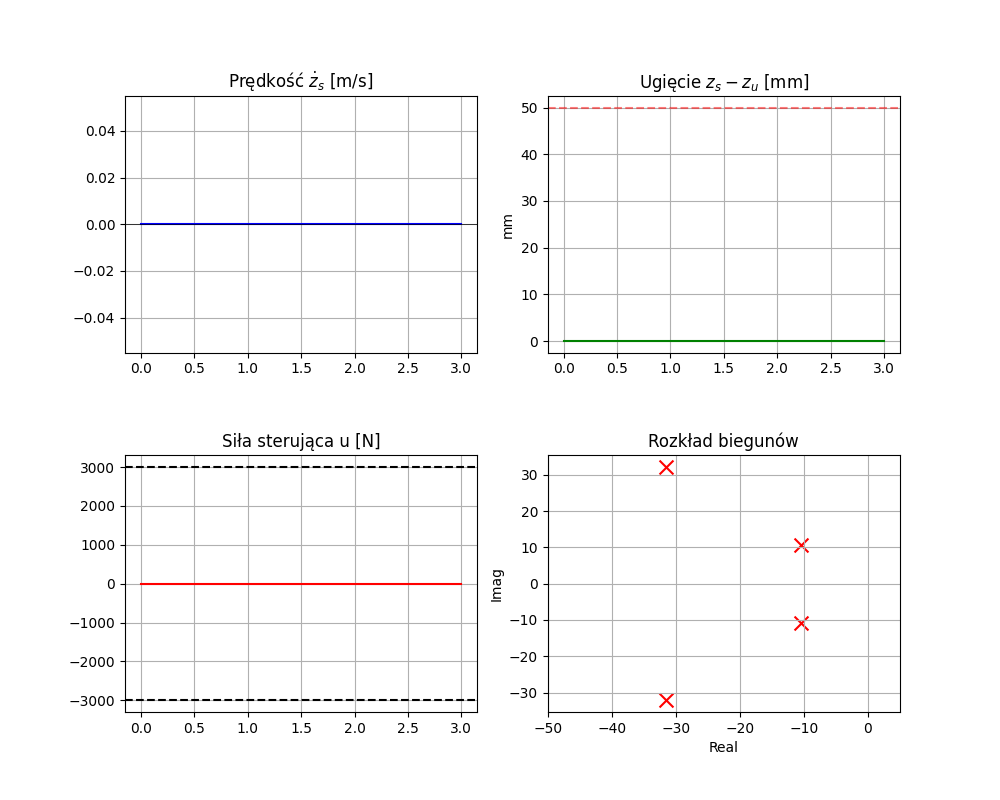

In [75]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def interactive_pole_placement(model):
    # Parametry symulacji
    t_sim = np.linspace(0, 3, 1000)
    
    def plot_response(zeta, omega_n, pole_factor):
        # --- POPRAWKA: Zamknięcie poprzednich wykresów, aby uniknąć wycieku pamięci ---
        plt.close('all')
        
        # 1. Wyznaczenie biegunów
        # Para dominująca (nadwozie)
        p_dom_real = -zeta * omega_n
        p_dom_imag = omega_n * np.sqrt(1 - zeta**2)
        p1 = complex(p_dom_real, p_dom_imag)
        p2 = complex(p_dom_real, -p_dom_imag)
        
        # Para szybka (koło) - np. pole_factor razy szybciej
        omega_fast = omega_n * pole_factor
        p_fast_real = -0.7 * omega_fast # Dajemy też pewne tłumienie
        p_fast_imag = omega_fast * np.sqrt(1 - 0.7**2)
        p3 = complex(p_fast_real, p_fast_imag)
        p4 = complex(p_fast_real, -p_fast_imag)
        
        desired_poles = [p1, p2, p3, p4]
        
        # 2. Obliczenie K metodą Ackermanna/place
        try:
            K = ct.place(model.A, model.B, desired_poles)
        except Exception as e:
            print(f"Błąd obliczania K: {e}")
            return

        # 3. Symulacja układu zamkniętego
        # Macierz A zamknięta: A_cl = A - B*K
        A_cl = model.A - model.B @ K
        # Wejście to r (droga). W macierzy E pierwsza kolumna odpowiada r.
        B_r = model.E[:, [0]] 
        
        # Definiujemy wyjścia do obserwacji: [zs_dot, zu-r, zs-zu, u]
        # y1 = zs_dot (x2), y2 = zu-r (x3), y3 = zs-zu (x1), y4 = u (-Kx)
        C_sim = np.vstack([
            [0, 1, 0, 0],      # zs_dot
            [0, 0, 1, 0],      # zu-r
            [1, 0, 0, 0],      # zs-zu
            -K                 # u (sterowanie)
        ])
        D_sim = np.zeros((4, 1))
        
        sys_cl = ct.ss(A_cl, B_r, C_sim, D_sim)
        
        # Wymuszenie: skok 0.05m (krawężnik)
        r_height = 0.05
        T, y = ct.step_response(sys_cl, T=t_sim)
        
        # Usunięcie zbędnych wymiarów (squeeze)
        y = np.squeeze(y) * r_height 
        
        # Rozpakowanie wyników
        zs_dot = y[0]
        zu_r = y[1]
        zs_zu = y[2]
        u_val = y[3]
        
        # 4. Sprawdzenie wymagań
        # Teoretyczny czas regulacji
        ts_theory = 4 / (zeta * omega_n)
        
        # Metryki
        mp_val = np.max(np.abs(zs_zu)) * 1000 # w mm
        max_u = np.max(np.abs(u_val))
        
        # Kolory statusów
        c_ts = 'green' if ts_theory < 0.4 else 'red'
        c_mp = 'green' if (np.max(zs_zu)/r_height) < 0.1 else 'orange' 
        c_u = 'green' if max_u <= model.u_max else 'red'
        
        # 5. Wykresy
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        plt.subplots_adjust(hspace=0.4)
        
        # A. Prędkość nadwozia
        ax = axes[0, 0]
        ax.plot(T, zs_dot, 'b')
        ax.set_title(r'Prędkość $\dot{z}_s$ [m/s]')
        ax.grid(True)
        ax.axhline(0, color='k', lw=0.5)
        
        # B. Ugięcie zawieszenia
        ax = axes[0, 1]
        ax.plot(T, zs_zu * 1000, 'g') # mm
        ax.set_title(r'Ugięcie $z_s - z_u$ [mm]')
        ax.set_ylabel('mm')
        ax.grid(True)
        ax.axhline(50, color='r', linestyle='--', alpha=0.5, label='Wymuszenie')
        
        # C. Sterowanie
        ax = axes[1, 0]
        ax.plot(T, u_val, 'r')
        ax.set_title(f'Siła sterująca u [N]')
        ax.grid(True)
        ax.axhline(model.u_max, color='k', linestyle='--', label='Limit')
        ax.axhline(-model.u_max, color='k', linestyle='--')
        if max_u > model.u_max:
            ax.text(0.0, model.u_max, " NASYCENIE!", color='red', fontweight='bold', va='bottom')
            
        # D. Mapa biegunów
        ax = axes[1, 1]
        real_parts = [p.real for p in desired_poles]
        imag_parts = [p.imag for p in desired_poles]
        ax.scatter(real_parts, imag_parts, c='r', marker='x', s=100)
        ax.set_title('Rozkład biegunów')
        ax.set_xlabel('Real')
        ax.set_ylabel('Imag')
        ax.grid(True)
        ax.set_xlim([-50, 5])
        
        # Wypisanie metryk
        print(f"--- WYNIKI (skok r = {r_height*100:.0f} cm) ---")
        print(f"Teoretyczny czas regulacji ts: {ts_theory:.3f} s (Wymagane < 0.4s) -> {c_ts.upper()}")
        print(f"Max siła sterująca: {max_u:.1f} N (Limit 3000 N) -> {c_u.upper()}")
        print(f"Max ugięcie (odchyłka): {mp_val:.1f} mm")
        print(f"K = {np.array2string(K, precision=2)}")

    # Definicja suwaków
    w_zeta = FloatSlider(min=0.1, max=1.2, step=0.05, value=0.7, description='Zeta')
    w_omega = FloatSlider(min=1.0, max=50.0, step=1.0, value=15.0, description='Omega_n')
    w_factor = FloatSlider(min=1.0, max=10.0, step=0.5, value=3.0, description='Factor kół')

    interact(plot_response, zeta=w_zeta, omega_n=w_omega, pole_factor=w_factor)

# Uruchomienie
interactive_pole_placement(model)